# Spatial Neighbourhood Analysis of mIF Data
## Systems Biology Lab — University of Warsaw, MIM

**Two × 1.5-hour sessions — BSc Bioinformatics, 3rd year**

---

### Background
Last week you characterised tumour tissue by dividing slides into **square patches**, summarising each patch as a cell-type histogram, and clustering those histograms. Today we go one level deeper: instead of analysing regions of space, we analyse the **local neighbourhood of every individual cell**.

The result — a *neighbourhood composition vector* or **"bag of cells"** — captures what surrounds each cell. Clustering these bags reveals discrete **spatial niches**: recurring microenvironments that may have distinct biological and clinical significance.

### Data
- 15 NSCLC (non-small-cell lung cancer) patient samples
- Each file: ~1.2 million cells, columns include spatial coordinates (`nucleus.x`, `nucleus.y` in µm), `cell.type`, `tissue.type`, ROI flags
- Cell types: `CD15-Tumor`, `CD15+Tumor`, `Tcell`, `Bcell`, `BnTcell`, `Macrophage`, `DC`, `Neutrophil`, `other`

### Coordinate scale
Coordinates are in **micrometres (µm)**. Typical cell diameter ≈ 12 µm, so 50 µm ≈ 4 cell diameters — a sensible first choice for neighbourhood radius.

## Setup — imports and configuration

In [1]:

!pip install umap-learn



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [9]:
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score

# umap-learn  (install with: pip install umap-learn)
import umap

# ── Constants ────────────────────────────────────────────────────────────────
CELL_TYPES = [
    "CD15-Tumor", "CD15+Tumor", "Tcell", "Bcell",
    "BnTcell", "Macrophage", "DC", "Neutrophil", "other"
]
N_TYPES = len(CELL_TYPES)
CT_TO_IDX = {ct: i for i, ct in enumerate(CELL_TYPES)}

# Fixed colour palette for cell types
CT_PALETTE = dict(zip(CELL_TYPES,
    ["#e6194b","#f58231","#3cb44b","#4363d8",
     "#911eb4","#42d4f4","#f032e6","#bfef45","#aaaaaa"]))

# Fixed colour palette for spatial niches (up to 8)
NICHE_PALETTE = ["#e41a1c","#377eb8","#4daf4a","#984ea3",
                 "#ff7f00","#a65628","#f781bf","#999999"]

DATA_DIR = "files_with_cell_types"
SAMPLE_FILES = sorted([f"{DATA_DIR}/{samp_file}" for samp_file in os.listdir(DATA_DIR)])
print(f"Found {len(SAMPLE_FILES)} sample files")

for i, sample_file in enumerate(SAMPLE_FILES):
    print(f"[{i+1}]: {sample_file}")

Found 15 sample files
[1]: files_with_cell_types/LUNG-NSCLC2-0558-FIXT-01-IF1-01_#_cells_properties_#_f9e776cbf3f124bd9a0d3af7ab4423ba.tsv.gz.csv
[2]: files_with_cell_types/LUNG-NSCLC2-0565-FIXT-01-IF1-01_#_cells_properties_#_12cf4d92f8de6204055505affdf85e90.tsv.gz.csv
[3]: files_with_cell_types/LUNG-NSCLC2-0587-FIXT-01-IF1-01_#_cells_properties_#_fb439474f2166fe87b6d3087643b2af3.tsv.gz.csv
[4]: files_with_cell_types/LUNG-NSCLC2-0591-FIXT-01-IF1-01_#_cells_properties_#_b17f2afaad57821d4888ff6ba7f4b179.tsv.gz.csv
[5]: files_with_cell_types/LUNG-NSCLC2-0593-FIXT-01-IF1-01_#_cells_properties_#_d070103e8b485c517639081c33e45ded.tsv.gz.csv
[6]: files_with_cell_types/LUNG-NSCLC2-0612-FIXT-01-IF1-01_#_cells_properties_#_c948f5405a3f2243d3ef6d678823d805.tsv.gz.csv
[7]: files_with_cell_types/LUNG-NSCLC2-0613-FIXT-01-IF1-01_#_cells_properties_#_53ec91fc9c63f3088eb688a53912ac53.tsv.gz.csv
[8]: files_with_cell_types/LUNG-NSCLC2-0616-FIXT-01-IF1-01_#_cells_properties_#_99f9f40cba303b42b5a251859509f0

---
# Session 1 — Spatial Graphs and Neighbourhood Composition

### Learning objectives
By the end of this session you will be able to:
1. Load mIF cell-level data and build a spatial coordinate array
2. Construct k-NN and radius-based neighbourhood graphs with `scipy.spatial.cKDTree`
3. Summarise each cell's neighbourhood as a fractional composition vector (the *bag of cells*)
4. Visualise spatial heterogeneity of neighbourhood composition for a single patient

---
## Exercise 1.1 — Loading Data and Sanity Checks *(20 min)*

**Biological motivation**  
Before any spatial analysis, understand your data: how many cells, how they distribute across tissue compartments, and whether the spatial scale makes sense biologically. A single slide may span several centimetres and contain >1 million cells — the choices you make here propagate through everything else.

> **Tip:** With 1.2 million points, plotting everything will freeze matplotlib.  
> Always **subsample** before plotting: `df.sample(50_000, random_state=42)`

In [13]:
# Load one patient
df = pd.read_csv(SAMPLE_FILES[0])
print(f"Shape: {df.shape}")

for col in df.columns:
    print(col)

Shape: (1291514, 21)
Unnamed: 0
cell.ID
nucleus.x
nucleus.y
CD15.score
CK.score
CD3.score
CD11c.score
CD20.score
CD163.score
CD15.score.normalized
CK.score.normalized
CD3.score.normalized
CD11c.score.normalized
CD20.score.normalized
CD163.score.normalized
tissue.type
phenotype
in.ROI.next_to_tumor_tissue
in.ROI.tumor_tissue
cell.type


In [14]:
# Task 1 — Cell-type and tissue-type distributions
print("Cell type counts:")
print(df["cell.type"].value_counts())
print("\nTissue type counts:")
print(df["tissue.type"].value_counts())

Cell type counts:
cell.type
other         476417
Tcell         311323
Macrophage    190569
CD15-Tumor    185318
Neutrophil     46722
Bcell          41490
BnTcell        23710
CD15+Tumor     15396
DC               569
Name: count, dtype: int64

Tissue type counts:
tissue.type
stroma    1042582
tumor      248932
Name: count, dtype: int64


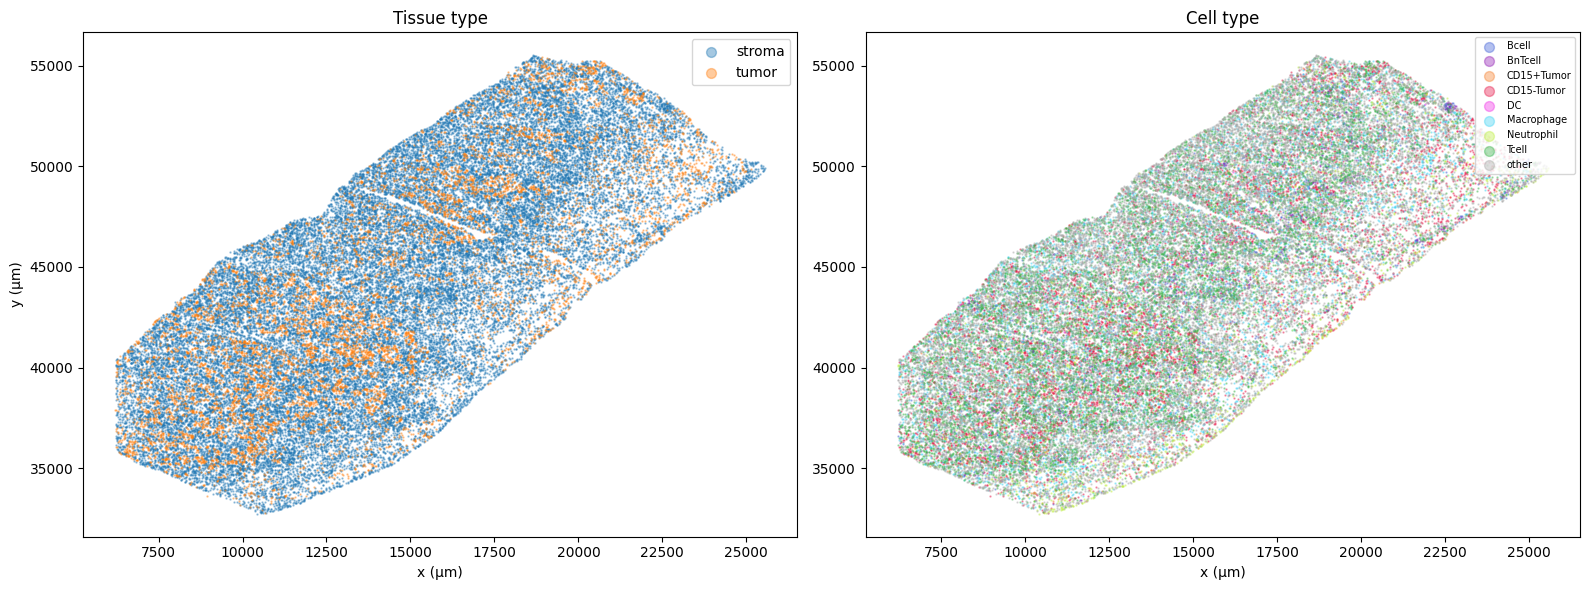

In [15]:
# Task 2 — Spatial scatter plots (subsample for speed)
sub = df.sample(50_000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: tissue type
for ttype, grp in sub.groupby("tissue.type"):
    axes[0].scatter(grp["nucleus.x"], grp["nucleus.y"],
                    s=0.5, alpha=0.4, label=ttype)
axes[0].set_title("Tissue type")
axes[0].set_xlabel("x (µm)")
axes[0].set_ylabel("y (µm)")
axes[0].legend(markerscale=10)

# Right: cell type
for ct, grp in sub.groupby("cell.type"):
    axes[1].scatter(grp["nucleus.x"], grp["nucleus.y"],
                    s=0.5, alpha=0.4, color=CT_PALETTE.get(ct, "grey"), label=ct)
axes[1].set_title("Cell type")
axes[1].set_xlabel("x (µm)")
axes[1].legend(markerscale=10, fontsize=7, loc="upper right")

plt.tight_layout()
plt.show()

**Discussion questions**
1. The coordinates are in µm. Given a typical cell diameter of ~12 µm, roughly how many cell diameters span the full slide?
2. Do T cells appear to cluster spatially, or are they distributed uniformly? What would you expect biologically?
3. Compare the two scatter plots. Where do tumour cells and immune cells co-localise?

---
## Exercise 1.2 — Building the Spatial Neighbourhood Graph *(25 min)*

**Biological motivation**  
A T cell near tumour cells may behave very differently from a T cell deep in the stroma. To characterise a cell's context we need a **neighbourhood** — the set of nearby cells within a biologically meaningful distance.

Two graph types answer different questions:
- **k-NN graph** — fixed number of contacts; normalises for tissue density differences
- **Radius graph** — all cells within *r* µm; maps directly to physical signalling range (cytokines act over ~50–200 µm)

> ⚠️ `cKDTree.query(coords, k+1)` returns the cell itself as neighbour 0 — always slice it off with `[:, 1:]`

In [16]:
coords = df[["nucleus.x", "nucleus.y"]].values   # shape (N, 2)
tree = cKDTree(coords)

# ── k-NN graph ────────────────────────────────────────────────────────────────
K = 10
distances, knn_indices = tree.query(coords, k=K + 1)   # +1 because self is included
knn_indices  = knn_indices[:, 1:]    # shape (N, K) — exclude self
knn_distances = distances[:, 1:]

print(f"k-NN graph built: {knn_indices.shape}")
print(f"Mean nearest-neighbour distance: {knn_distances[:, 0].mean():.1f} µm")

k-NN graph built: (1291514, 10)
Mean nearest-neighbour distance: 8.4 µm


In [17]:
# ── Radius graph ─────────────────────────────────────────────────────────────
R = 50   # µm — roughly 4 cell diameters

# Note: query_ball_point is slow on 1.2M cells; work on a subset for exploration
subset_idx = np.random.RandomState(42).choice(len(df), size=20_000, replace=False)
coords_sub = coords[subset_idx]
tree_sub = cKDTree(coords_sub)

radius_indices = tree_sub.query_ball_point(coords_sub, r=R)

# Remove self from each list
radius_indices = [
    [j for j in nbrs if j != i]
    for i, nbrs in enumerate(radius_indices)
]

n_neighbours = np.array([len(nbrs) for nbrs in radius_indices])
print(f"Radius graph (r={R} µm) — neighbour count stats:")
print(pd.Series(n_neighbours).describe().round(1))

Radius graph (r=50 µm) — neighbour count stats:
count    20000.0
mean         0.8
std          0.9
min          0.0
25%          0.0
50%          1.0
75%          1.0
max          6.0
dtype: float64


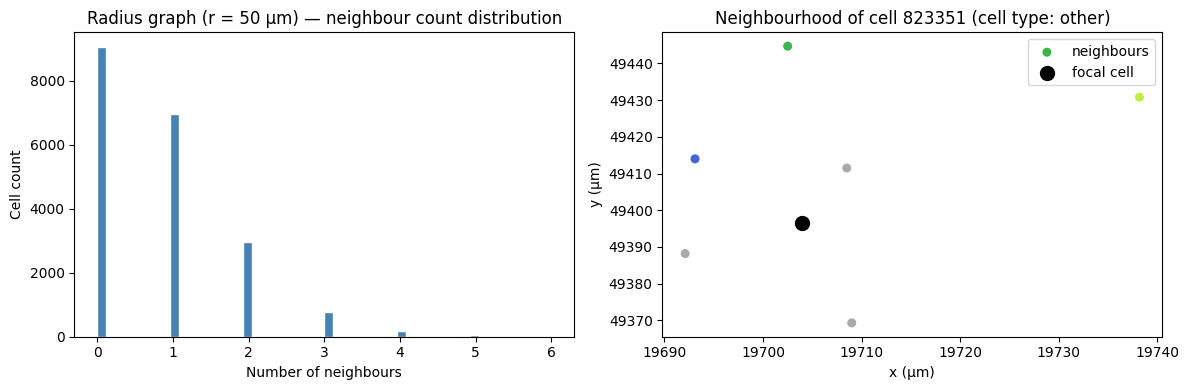

In [18]:
# Task — Distribution of neighbour counts (radius graph)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(n_neighbours, bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Number of neighbours")
axes[0].set_ylabel("Cell count")
axes[0].set_title(f"Radius graph (r = {R} µm) — neighbour count distribution")

# Task — Visualise the neighbourhood of a single cell
# Pick a cell near the tumour; here we just pick one with many neighbours
focus_i = int(np.argmax(n_neighbours))
focus_global = subset_idx[focus_i]
nbr_globals = subset_idx[radius_indices[focus_i]]

axes[1].scatter(coords[nbr_globals, 0], coords[nbr_globals, 1],
                c=[CT_PALETTE.get(ct, "grey") for ct in df.iloc[nbr_globals]["cell.type"]],
                s=30, label="neighbours")
axes[1].scatter(coords[focus_global, 0], coords[focus_global, 1],
                c="black", s=100, zorder=5, label="focal cell")
axes[1].set_title(f"Neighbourhood of cell {focus_global} (cell type: {df.iloc[focus_global]['cell.type']})")
axes[1].legend()
axes[1].set_xlabel("x (µm)")
axes[1].set_ylabel("y (µm)")

plt.tight_layout()
plt.show()

**Discussion questions**
1. How would you choose `k` or `r` in practice? What biological reasoning supports your choice?
2. A cell in a dense region has closer k-NN neighbours than a cell in a sparse region. Is this a problem? When does it matter?
3. Does the neighbour-count distribution look unimodal? What would a bimodal distribution suggest about tissue organisation?

---
## Exercise 1.3 — Neighbourhood Composition Vectors (
) *(25 min)*

**Biological motivation**  
Last week each square tile was summarised as a vector of cell-type fractions. Now we do the same — but the 
 is the local neighbourhood of each individual cell. This gives **cell-level resolution**: a T cell surrounded mostly by tumour cells has a very different context from a T cell in a B-cell-rich lymphoid aggregate.

The result is a matrix of shape **(N cells × 9 cell types)** where each row is the fractional composition of that cell's neighbourhood.

> **Optimisation challenge:** First implement the loop version, then replace it with the vectorised one-hot approach — compare timing.

In [19]:
# ── Slow loop version (start here to understand the logic) ───────────────────
ct_array = df["cell.type"].map(CT_TO_IDX).fillna(-1).astype(int).values  # shape (N,)

N = len(df)
bags_loop = np.zeros((N, N_TYPES), dtype=np.float32)

for i in range(N):
    nbrs = knn_indices[i]                    # shape (K,)
    valid_ct = ct_array[nbrs]
    valid_ct = valid_ct[valid_ct >= 0]       # drop unknown cell types
    if len(valid_ct) > 0:
        for j in valid_ct:
            bags_loop[i, j] += 1
        bags_loop[i] /= len(valid_ct)

print("Loop version done — shape:", bags_loop.shape)

Loop version done — shape: (1291514, 9)


In [20]:
# ── Fast vectorised version ───────────────────────────────────────────────────
# One-hot encode all cells, then average over k-NN rows

# Replace -1 (unknown) with a dummy index = N_TYPES, then zero it out
ct_safe = ct_array.copy()
ct_safe[ct_safe < 0] = N_TYPES

one_hot = np.eye(N_TYPES + 1, dtype=np.float32)[ct_safe]  # shape (N, N_TYPES+1)
one_hot = one_hot[:, :N_TYPES]                             # drop the dummy column

# For each cell, average the one-hot vectors of its k neighbours
bags = one_hot[knn_indices].mean(axis=1)   # shape (N, N_TYPES)

print("Vectorised version done — shape:", bags.shape)
print(f"Max absolute difference from loop version: {np.abs(bags - bags_loop).max():.6f}")

Vectorised version done — shape: (1291514, 9)
Max absolute difference from loop version: 0.000000


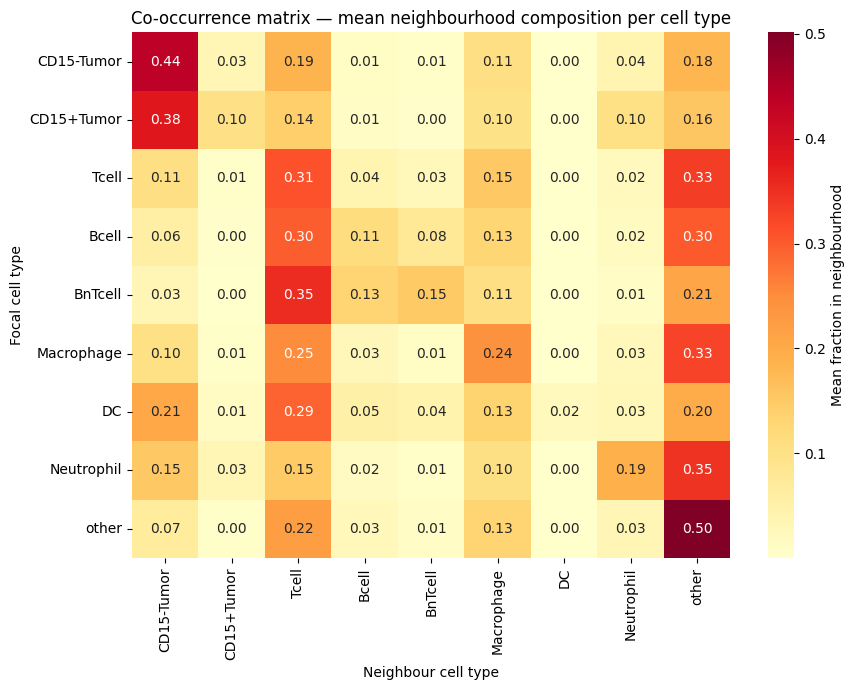

In [21]:
# Task — Co-occurrence heatmap (9 × 9)
# For each cell type: what is the mean fraction of each cell type in its neighbourhood?

cooccurrence = np.zeros((N_TYPES, N_TYPES), dtype=np.float32)
for i, ct in enumerate(CELL_TYPES):
    mask = (ct_array == i)
    if mask.sum() > 0:
        cooccurrence[i] = bags[mask].mean(axis=0)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cooccurrence, xticklabels=CELL_TYPES, yticklabels=CELL_TYPES,
            annot=True, fmt=".2f", cmap="YlOrRd", ax=ax,
            cbar_kws={"label": "Mean fraction in neighbourhood"})
ax.set_xlabel("Neighbour cell type")
ax.set_ylabel("Focal cell type")
ax.set_title("Co-occurrence matrix — mean neighbourhood composition per cell type")
plt.tight_layout()
plt.show()

**Discussion questions**
1. A tumour cell might have 80% tumour-cell neighbours. Is this a 
 or just a reflection of global tissue composition?
2. How would you control for global cell-type abundance when interpreting co-occurrence?
3. Compare the co-occurrence matrix to what you would expect under a random (spatially shuffled) arrangement. Which off-diagonal entries are most surprising?

---
### Session 1 Wrap-Up
1. What is the analogy between last week's tile histograms and today's neighbourhood bags?
2. What information does a neighbourhood bag capture that a tile histogram cannot?
3. Name one biological scenario where radius-based neighbourhoods are more appropriate than k-NN.

---
# Session 2 — Clustering Niches, Visualisation, and Cross-Sample Analysis

### Learning objectives
By the end of this session you will be able to:
1. Cluster neighbourhood bags to define discrete **spatial niches** using k-means
2. Visualise niche assignments back on the tissue and interpret them biologically
3. Apply UMAP to explore niche structure in low dimensions
4. Assess cross-sample consistency of spatial niches across patients
5. Critically compare the niche-based and patch-based approaches

---
## Exercise 2.1 — Clustering Neighbourhood Bags into Spatial Niches *(25 min)*

**Biological motivation**  
With >1 million cells, we cannot reason about each one individually. Clustering the bag matrix groups cells that live in similar microenvironments — these groups are our **spatial niches**.

The number of niches is a **biological hypothesis**, not a parameter to optimise blindly. Think about what niches you expect in a lung tumour: tumour core, immune-excluded stroma, immune-infiltrated border, lymphoid aggregates...

> ⚠️ Use `MiniBatchKMeans` — it handles 1M+ rows in seconds. `KMeans` will take several minutes.

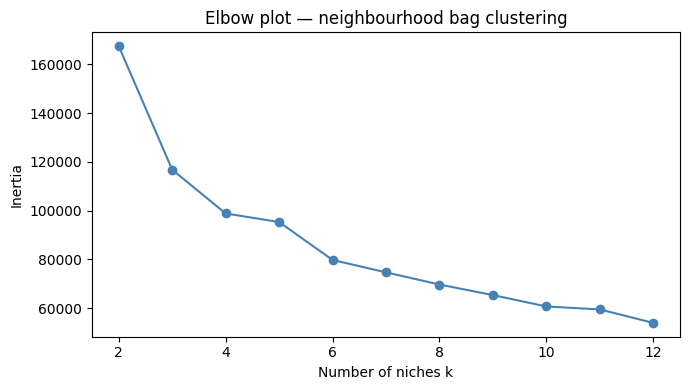

In [22]:
# L1-normalise (rows already sum ≈ 1, but this corrects numerical noise)
X = normalize(bags, norm="l1")

# ── Elbow plot — choose number of niches ─────────────────────────────────────
ks = range(2, 13)
inertias = []
for k in ks:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=5)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(ks), inertias, "o-", color="steelblue")
plt.xlabel("Number of niches k")
plt.ylabel("Inertia")
plt.title("Elbow plot — neighbourhood bag clustering")
plt.tight_layout()
plt.show()

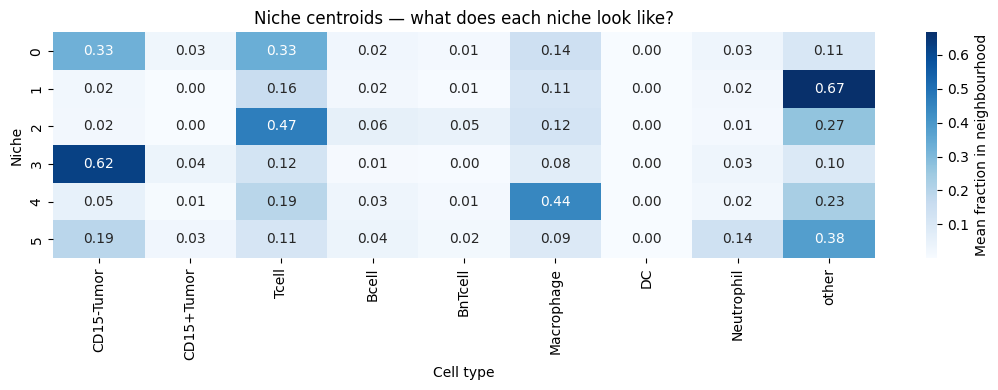


Niche size distribution:
niche
0    123796
1    395667
2    316730
3    136251
4    153768
5    165302
Name: count, dtype: int64


In [23]:
# ── Fit final model ───────────────────────────────────────────────────────────
K_NICHES = 6    # adjust based on elbow plot and biological reasoning

km_final = MiniBatchKMeans(n_clusters=K_NICHES, random_state=42, n_init=10)
niche_labels = km_final.fit_predict(X)
df["niche"] = niche_labels

# Task 1 — Cluster centroids heatmap (name each niche biologically)
centroids = pd.DataFrame(km_final.cluster_centers_, columns=CELL_TYPES)

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(centroids, annot=True, fmt=".2f", cmap="Blues", ax=ax,
            cbar_kws={"label": "Mean fraction in neighbourhood"})
ax.set_xlabel("Cell type")
ax.set_ylabel("Niche")
ax.set_title("Niche centroids — what does each niche look like?")
plt.tight_layout()
plt.show()

print("\nNiche size distribution:")
print(df["niche"].value_counts().sort_index())

/home/kchadzynski/Pulpit/mimuw/BiologiaSystemów/CW6/venv/lib64/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/kchadzynski/Pulpit/mimuw/BiologiaSystemów/CW6/venv/lib64/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


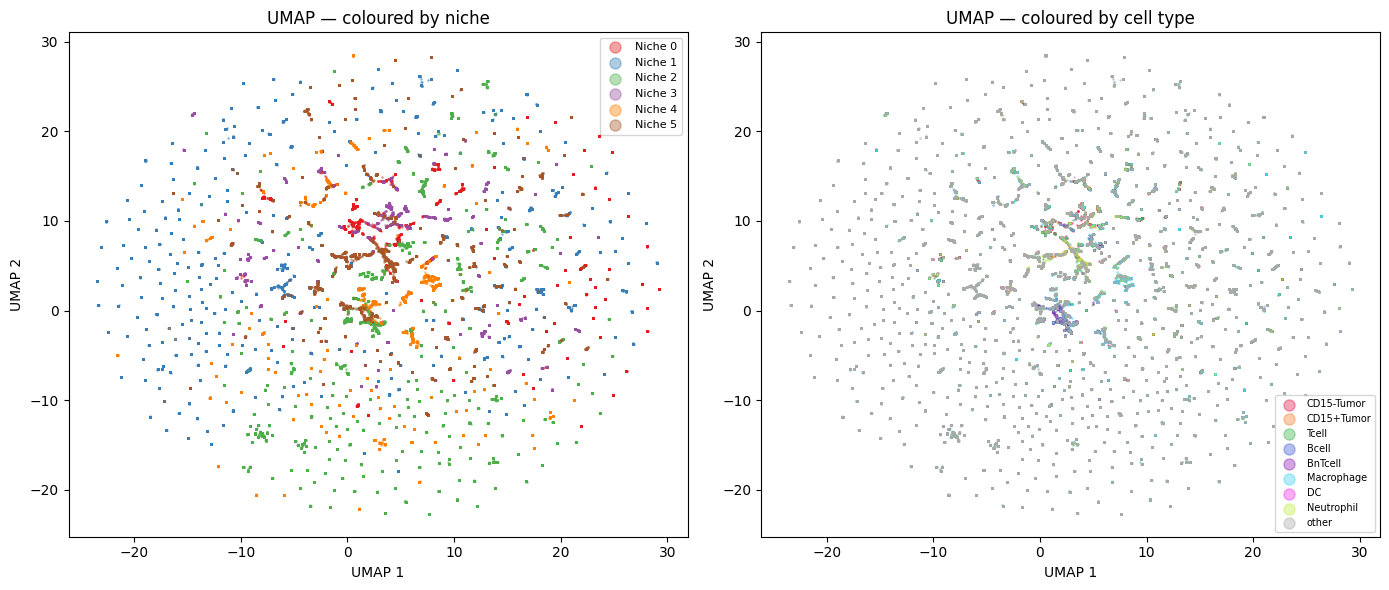

In [38]:
# Task 2 — UMAP on a 50k subsample, coloured by niche
rng = np.random.RandomState(42)
sub_idx = rng.choice(len(X), size=50_000, replace=False)

reducer = umap.UMAP(n_components=2, metric="cosine", random_state=42, n_neighbors=15)
embedding = reducer.fit_transform(X[sub_idx])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for niche_id in range(K_NICHES):
    mask = niche_labels[sub_idx] == niche_id
    axes[0].scatter(embedding[mask, 0], embedding[mask, 1],
                    s=1, alpha=0.4, c=NICHE_PALETTE[niche_id], label=f"Niche {niche_id}")
axes[0].set_title("UMAP — coloured by niche")
axes[0].legend(markerscale=8, fontsize=8)

for ct, color in CT_PALETTE.items():
    mask = df.iloc[sub_idx]["cell.type"].values == ct
    axes[1].scatter(embedding[mask, 0], embedding[mask, 1],
                    s=1, alpha=0.4, c=color, label=ct)
axes[1].set_title("UMAP — coloured by cell type")
axes[1].legend(markerscale=8, fontsize=7)

for ax in axes:
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.show()

**Discussion questions**
1. The elbow plot rarely gives a clean answer. What biological knowledge could guide your choice of *k*?
2. Assign a biological name to each niche based on its centroid. Could you justify these names to a pathologist?
3. How sensitive are niche assignments to the random seed? Try `random_state=0` vs `random_state=99`.

---
## Exercise 2.2 — Spatial Visualisation of Niches *(20 min)*

**Biological motivation**  
Cluster labels are numbers until you project them back onto the tissue. The spatial map reveals whether niches are biologically coherent: do they form contiguous regions? Are immune niches at the tumour boundary? Does the niche map recapitulate what a pathologist would draw?

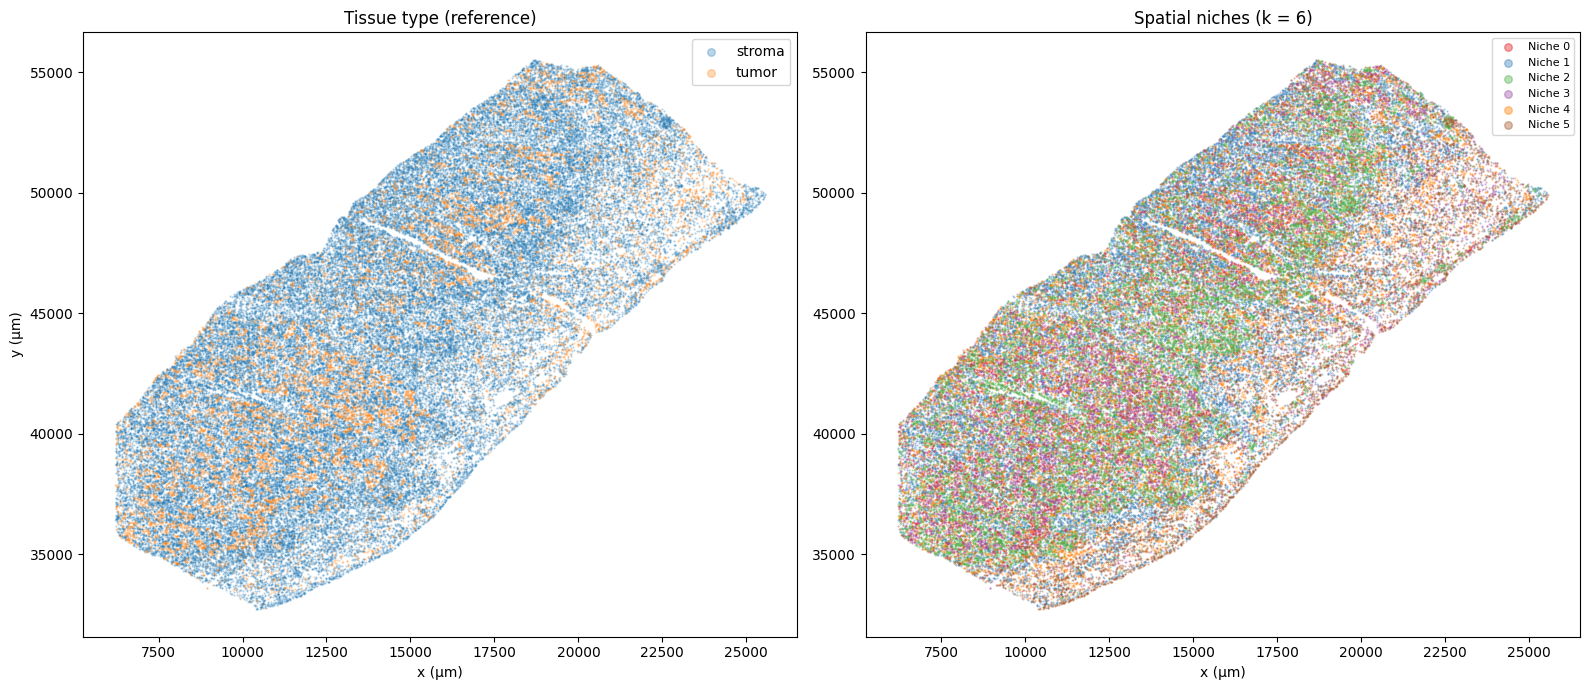

In [26]:
sub = df.sample(80_000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: tissue type reference
for ttype, grp in sub.groupby("tissue.type"):
    axes[0].scatter(grp["nucleus.x"], grp["nucleus.y"],
                    s=0.3, alpha=0.3, label=ttype)
axes[0].set_title("Tissue type (reference)")
axes[0].legend(markerscale=10)
axes[0].set_xlabel("x (µm)")
axes[0].set_ylabel("y (µm)")

# Right: niche assignments
for niche_id in range(K_NICHES):
    grp = sub[sub["niche"] == niche_id]
    axes[1].scatter(grp["nucleus.x"], grp["nucleus.y"],
                    s=0.3, alpha=0.4, c=NICHE_PALETTE[niche_id], label=f"Niche {niche_id}")
axes[1].set_title(f"Spatial niches (k = {K_NICHES})")
axes[1].legend(markerscale=10, fontsize=8)
axes[1].set_xlabel("x (µm)")

plt.tight_layout()
plt.show()

Tissue type composition per niche:
tissue.type  stroma  tumor
niche                     
0             0.423  0.577
1             0.988  0.012
2             0.971  0.029
3             0.146  0.854
4             0.905  0.095
5             0.803  0.197


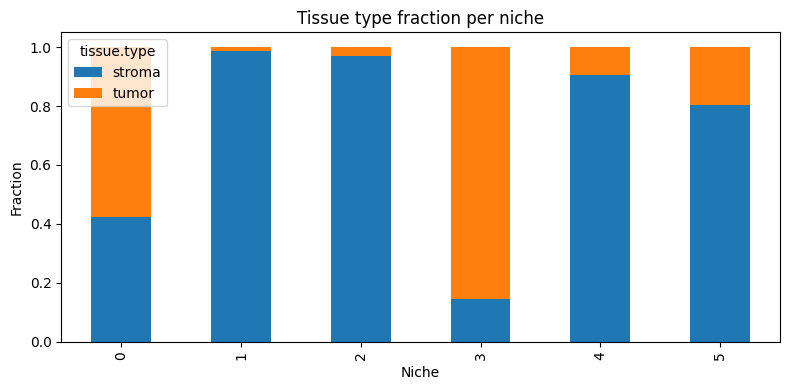

In [27]:
# Task — For each niche, what fraction of cells are in each tissue type?
niche_tissue = pd.crosstab(df["niche"], df["tissue.type"], normalize="index")
print("Tissue type composition per niche:")
print(niche_tissue.round(3))

niche_tissue.plot(kind="bar", stacked=True, figsize=(8, 4),
                  title="Tissue type fraction per niche",
                  xlabel="Niche", ylabel="Fraction")
plt.tight_layout()
plt.show()

**Discussion questions**
1. Do niche boundaries align with the tissue-type boundary (stroma/tumour)? Where do they diverge?
2. Are immune niches spatially contiguous (suggesting lymphoid aggregates) or diffuse?
3. If you were a pathologist, which niche would you call "immune desert", which "inflamed", and which "excluded"?
4. Try changing `K_NICHES` to 4 and 8 in Exercise 2.1. How do the spatial maps change?

---
## Exercise 2.3 — Cross-Sample Consistency of Spatial Niches *(25 min)*

**Biological motivation**  
A spatial niche identified in one patient is only biologically meaningful if it **recurs across patients** — otherwise it might be a sample-specific artefact. This exercise checks whether niches transfer to new patients, and whether patients differ in niche abundance in ways that might relate to clinical outcome.

In [33]:
def compute_bags_knn(df_sample, k=10):
    """Compute neighbourhood bag matrix for a sample (vectorised)."""
    coords_s = df_sample[["nucleus.x", "nucleus.y"]].values
    tree_s = cKDTree(coords_s)
    _, idx = tree_s.query(coords_s, k=k + 1)
    idx = idx[:, 1:]  # exclude self

    ct_arr = df_sample["cell.type"].map(CT_TO_IDX).fillna(N_TYPES).astype(int).values
    oh = np.eye(N_TYPES + 1, dtype=np.float32)[ct_arr][:, :N_TYPES]
    return oh[idx].mean(axis=1)  # (N, N_TYPES)


# Process 3 additional patients (transfer clustering from km_final)
results = {}
for fpath in SAMPLE_FILES[1:4]:
    sample_id = os.path.basename(fpath).split("_")[0]
    print(f"Processing {sample_id}...", end=" ")
    df_s = pd.read_csv(fpath)
    bags_s = compute_bags_knn(df_s)
    df_s["niche"] = km_final.predict(normalize(bags_s, norm="l1"))
    results[sample_id] = df_s
    print("done")

Processing LUNG-NSCLC2-0565-FIXT-01-IF1-01... done
Processing LUNG-NSCLC2-0587-FIXT-01-IF1-01... done
Processing LUNG-NSCLC2-0591-FIXT-01-IF1-01... done


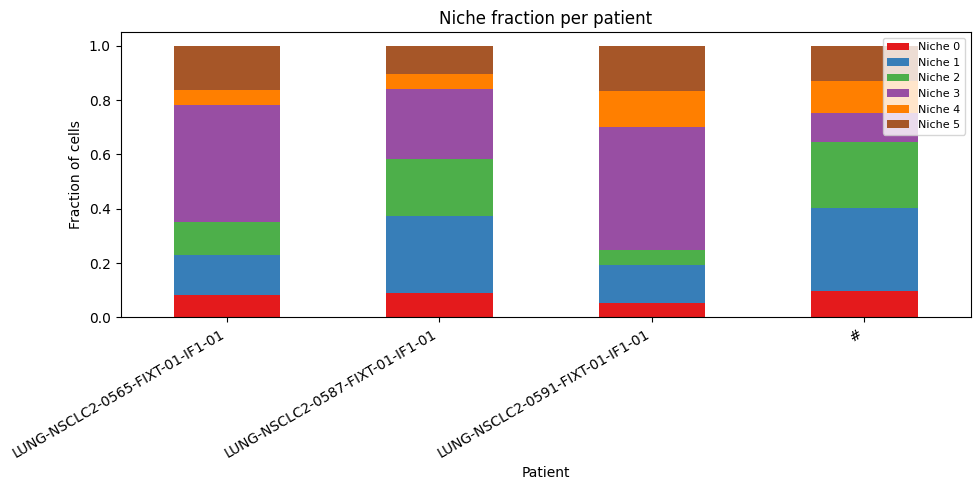

In [34]:
# Add patient 1 (already computed)
patient1_id = os.path.basename(SAMPLE_FILES[0]).split("_")[1]
results[patient1_id] = df

# ── Stacked bar: niche fractions per patient ──────────────────────────────────
niche_fractions = pd.DataFrame({
    pid: dfs["niche"].value_counts(normalize=True).sort_index()
    for pid, dfs in results.items()
}).T.fillna(0)
niche_fractions.columns = [f"Niche {i}" for i in niche_fractions.columns]

colors = NICHE_PALETTE[:K_NICHES]
niche_fractions.plot(kind="bar", stacked=True, figsize=(10, 5),
                     color=colors, title="Niche fraction per patient")
plt.ylabel("Fraction of cells")
plt.xlabel("Patient")
plt.xticks(rotation=30, ha="right")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

In [35]:
# ── Cosine similarity of niche 0 centroid across patients ────────────────────
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

print("Mean bag vector for Niche 0 across patients (cosine similarity to patient 1):")
ref_vector = bags[niche_labels == 0].mean(axis=0)
for pid, dfs in results.items():
    if pid == patient1_id:
        continue
    bags_s = compute_bags_knn(dfs)
    niche0_mean = bags_s[dfs["niche"].values == 0].mean(axis=0)
    print(f"  {pid}: cosine sim = {cosine_sim(ref_vector, niche0_mean):.3f}")

Mean bag vector for Niche 0 across patients (cosine similarity to patient 1):
  LUNG-NSCLC2-0565-FIXT-01-IF1-01: cosine sim = 0.992
  LUNG-NSCLC2-0587-FIXT-01-IF1-01: cosine sim = 0.997
  LUNG-NSCLC2-0591-FIXT-01-IF1-01: cosine sim = 0.845


**Discussion questions**
1. Which niche shows the most inter-patient variation in abundance? What biology might explain this?
2. If the cosine similarity of Niche 0 across patients is low, what does that mean for the transferability of the clustering?
3. How would you test whether niche abundance correlates with a clinical variable such as survival or response to therapy?

---
## Exercise 2.4 — Patch-Based vs. Neighbourhood-Based: Critical Comparison *(15 min)*

**Biological motivation**  
Both approaches summarise local cellular composition — but at different scales and with different units of analysis. Understanding when to use which is a key analytical judgement call.

| | Patch-based (last week) | Neighbourhood-based (this week) |
|---|---|---|
| **Unit** | Fixed square region of space | Individual cell |
| **Scale** | ~200 × 200 µm tile | ~50 µm radius per cell |
| **Boundary handling** | Straddles boundaries | Adapts to local density |
| **Output** | One vector per tile | One vector per cell |
| **Downstream question** | What regions exist? | What context does each cell live in? |

In [36]:
# If you have patch cluster assignments from last week, load them here:
# df["patch_cluster"] = ...   (integer labels from tile k-means)

# Cross-tabulation: which neighbourhood niches appear inside each patch cluster?
# (Run this cell only if patch_cluster column is available)

if "patch_cluster" in df.columns:
    cross_tab = pd.crosstab(df["patch_cluster"], df["niche"], normalize="index")
    cross_tab.columns = [f"Niche {i}" for i in cross_tab.columns]

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.heatmap(cross_tab, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax)
    ax.set_title("Neighbourhood niche composition within each patch cluster")
    ax.set_xlabel("Neighbourhood niche")
    ax.set_ylabel("Patch cluster")
    plt.tight_layout()
    plt.show()
else:
    print("No patch_cluster column found — discuss the questions below without the plot.")

No patch_cluster column found — discuss the questions below without the plot.


**Discussion questions — answer in pairs, then discuss as a group**

1. **Resolution:** Last week's patches summarise ~200 × 200 µm regions; this week's neighbourhoods summarise a ~50 µm radius. What is captured by one that is missed by the other?

2. **Boundary effects:** A patch at the tumour-stroma boundary mixes signals from both compartments. How does the neighbourhood approach handle this differently?

3. **Cell identity:** In the patch approach you lose track of individual cells — the patch is the unit of analysis. What new questions does cell-level tracking enable?

4. **Scale of question:** Which approach is more appropriate if your question is *"do T cells near tumour cells express higher exhaustion markers"*? Why?

5. **Neither is always better.** Describe a biological scenario where patch-based analysis gives a misleading result that neighbourhood analysis would catch — and vice versa.

---
### Session 2 Wrap-Up — Exit Questions
1. Define 
 in one sentence that a biologist (not a data scientist) would understand.
2. You have 15 patients. How would you test whether the abundance of the 
 niche predicts patient survival?
3. What would you need to add to this analysis to claim that a spatial niche is **causally** involved in tumour progression?

---
## Python Reference Card

### Spatial indexing
```python
from scipy.spatial import cKDTree
tree = cKDTree(coords)                         # build once; O(N log N)
dist, idx = tree.query(coords, k=k+1)          # k-NN; exclude self with [:,1:]
nbr_lists = tree.query_ball_point(coords, r)   # radius; returns list of lists
```

### Vectorised bag construction
```python
one_hot = np.eye(n_types, dtype=np.float32)[ct_array]  # (N, n_types)
bags = one_hot[knn_indices].mean(axis=1)                # (N, n_types)
```

### Clustering at scale
```python
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import normalize
X = normalize(bags, norm="l1")
km = MiniBatchKMeans(n_clusters=6, random_state=42, n_init=10)
labels = km.fit_predict(X)
```

### Dimensionality reduction
```python
import umap
reducer = umap.UMAP(n_components=2, metric="cosine", random_state=42)
embedding = reducer.fit_transform(X[subsample_idx])   # subsample to ~50k
```

### Cross-tabulation
```python
pd.crosstab(df["niche"], df["tissue.type"], normalize="index")
pd.crosstab(df["patch_cluster"], df["niche"], normalize="index")
```

---
## Extension Questions *(for fast students)*

1. **Spatial autocorrelation** — Compute Moran's I for the niche labels. Are spatial niches more autocorrelated than expected by chance?
2. **Neighbourhood of neighbourhoods** — Compute 2-hop composition (neighbours of neighbours). How do the clusters differ from 1-hop niches?
3. **Ligand-receptor co-localisation** — Which niches show the highest Macrophage + T cell co-occurrence? Quantify enrichment relative to a random baseline.
4. **Niche stability** — Remove 50% of cells at random before building the neighbourhood graph. How much do niche assignments change?
5. **Graph-based alternative** — Replace cKDTree + k-means with Delaunay triangulation + Leiden community detection (Squidpy). How do the resulting niches compare?